In [382]:
# Part 1 - Setup a Notebook to Brief Your Stakeholders
# 1. Create a Jupyter Notebook to track your results.

In [383]:
# 2. At the top of the notebook, add:
# 	A short title and your name.
# 	The business question written in your own words.

# G, Jay, Sean
# Do Loyalty App users spend more than Non-Users?

In [384]:
# 3. Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from scipy import stats

In [385]:
# Load freshmart_spend.csv into a DataFrame named spend_df.
df = pd.read_csv("data/freshmart.csv")

In [386]:
# 5. Display:
# .head() – peek at the first rows.
# .info() – check dtypes and nulls.
# .describe() grouped by group – compare means and medians.

df.head()

,group,spend
0,App User,65.450712
1,App User,55.926035
2,App User,67.715328
3,App User,80.845448
4,App User,54.487699


In [387]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   group   400 non-null    object 
 1   spend   400 non-null    float64
dtypes: float64(1), object(1)
memory usage: 6.4+ KB


In [388]:
df.groupby("group").describe()

spend                                                         \
          count       mean        std        min        25%        50%   
group                                                                    
App User  200.0  57.388436  13.965059  18.703823  47.423085  57.937122   
Non-User  200.0  53.288023  14.805057   3.380990  42.912437  53.182590   

                                 
                75%         max  
group                            
App User  65.512787   98.802537  
Non-User  62.308467  109.790972

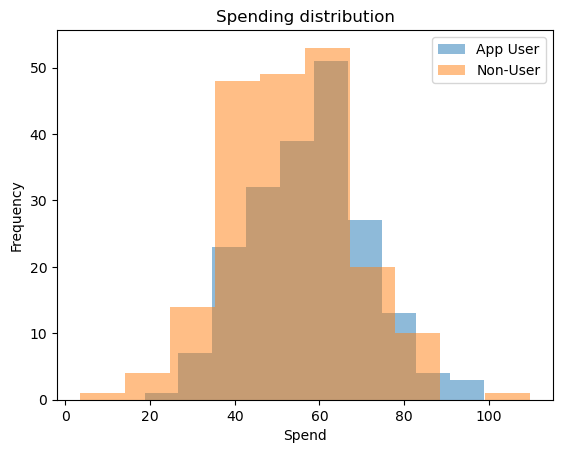

In [389]:
# 6. Visual checks for normality (one plot for each group):
# A histogram or a boxplot.
# Hints: Look for symmetry and extreme outliers.

fig, ax = plt.subplots()
ax.hist(df[df['group'] == 'App User']['spend'], alpha=0.5, label='App User')
ax.hist(df[df['group'] == 'Non-User']['spend'], alpha=0.5, label='Non-User')
ax.set_title('Spending distribution')
ax.set_xlabel('Spend')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()

In [390]:
# 7. Write one or two sentences on whether normality seems reasonable for a t-test.

It looks like a normal distribution. Reasonable outliers.

In [391]:
# Part 2 – Independent t-Test
# FreshMart wants solid evidence that app users spend more.

# 1. Set up hypotheses in plain language and symbols:
# 	(Null Hypothesis) H₀: μ₁ = μ₂
# 	(Alternative Hypothesis) H₁: μ₁ > μ₂

# Null Hypothesis: App had no effect on app users, so they spent same amount as non-users.
# Alternative Hypothesis: App had effect on making app users spend more than non-users.

In [392]:
# 2. Run stats.ttest_ind() with equal_var=False (Welch’s test handles unequal variances).
au_df = df[df["group"] == "App User"]
nu_df = df[df["group"] == "Non-User"]

ttest = stats.ttest_ind(au_df["spend"], nu_df["spend"], equal_var=False)

# 3. Print the test statistic and p-value.
print(ttest)

TtestResult(statistic=np.float64(2.849252420752362), pvalue=np.float64(0.004610620601609663), df=np.float64(396.6497915124304))


In [393]:
# 4. Decide:
# Is p < 0.05?
# Interpret your p-value and test results.

# Our p-value is 0.00, much less than 0.05.
# It means that the t-statistic of 2.85 is not random.

In [394]:
# 5. Explain any important information you learned from you test results
# to the stakeholders for FreshMart in a few sentences.

# App users performed better than non-users.
# There was significant difference in the average spends of the groups, and it was not by random chance.

In [395]:
# Part 3 – Simulating Best-Case and Worst-Case Monthly Profit
# 1. Use the mean and standard deviation for each group that you observed in your sample.
# 	Hint: your loc and scale for your normal distribution should be derived
# 	from the mean and std of your samples in the freshmart_spend.csv

# App users: 57.388436	13.965059
au_normal = np.random.normal(loc=57.388436, scale=13.965059)

# Non-users: 53.288023	14.805057
nu_normal = np.random.normal(loc=53.288023, scale=14.805057)

In [396]:
# 2. Assume for this month:
# 	1,000 App Users will visit.
# 	5,000 Non-Users will visit.
# 	The business has fixed costs of $292,000 this month.

[np.float64(57462.38071906647), np.float64(57005.43618946432), np.float64(57959.238034189664), np.float64(57495.31114757431), np.float64(56773.3938681669), np.float64(57375.41689387398), np.float64(57555.530208209835), np.float64(58077.15608293938), np.float64(57363.96743556335), np.float64(58442.835578220926), np.float64(56628.23456495573), np.float64(57035.93978605921), np.float64(57639.00219748586), np.float64(57662.87824440618), np.float64(57243.97788741674), np.float64(56852.84533131562), np.float64(57610.19548019446), np.float64(56660.2596772119), np.float64(57401.11385517579), np.float64(56916.76905100015), np.float64(57273.27545708792), np.float64(58172.705883656614), np.float64(57967.315563049626), np.float64(56828.59580055852), np.float64(56925.831293546624), np.float64(56998.2603668088), np.float64(57201.116856354405), np.float64(57220.563678999926), np.float64(57355.69528621665), np.float64(57246.57238244053), np.float64(57111.90704121269), np.float64(57814.41040396673), np

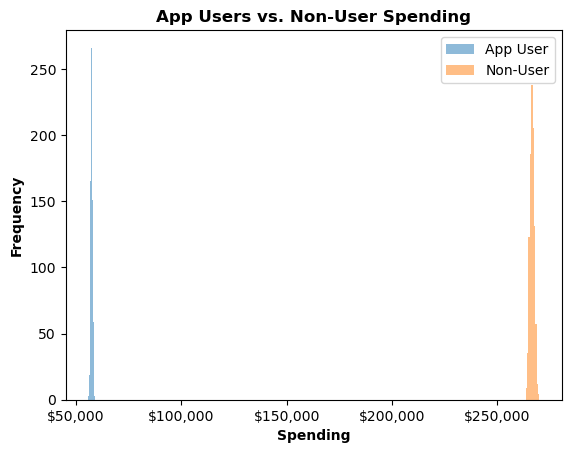

In [397]:
# 3. Simulate 1,000 scenarios for total revenue:
# 	The simulation should simulate the individual spending for 1,000 App Users plus the individual spending for 5,000 Non-App Users.
# 	You should do this simulation of both groups 1,000 times.
# 	For each scenario, draw 1,000 spending amounts for App Users from a normal distribution (use your sample mean and std).
# 	Draw 5,000 spending amounts for Non-Users from a normal distribution (use your sample mean and std).

# 4. Subtract the fixed cost from each scenario’s total revenue to get profit.
# 	Hint: Locate the fixed costs for the business above
# 	Sum both to get total revenue for that scenario.

def simulation(app_user_count, non_user_count, repetitions):

	au_list = []
	nu_list = []
	revenue_list = []

	# Set up loop
	while repetitions > 0:

		# Normal distributions for both groups
		au_normal = np.random.normal(loc=57.388436, scale=13.965059, size=app_user_count)
		nu_normal = np.random.normal(loc=53.288023, scale=14.805057, size=non_user_count)

		# Sum the trials
		au_sum = au_normal.sum()
		nu_sum = nu_normal.sum()

		# Add the sum to a list
		au_list.append(au_sum)
		nu_list.append(nu_sum)

		# Subtract the fixed cost from sum
		revenue = au_sum + nu_sum - 292000

		# Add revenue to list
		revenue_list.append(revenue)

		# Decrement loop counter
		repetitions -= 1

	# Returns three numbers
	return au_list, nu_list, revenue_list

thousand_au, thousand_nu, thousand_rev = simulation(1000, 5000, 1000)
print(thousand_au, thousand_nu)

# Histogram check
fig, ax = plt.subplots()
ax.hist(thousand_au, alpha=0.5, label='App User')
ax.hist(thousand_nu, alpha=0.5, label='Non-User')
ax.set_title("App Users vs. Non-User Spending", weight="bold")
ax.set_xlabel('Spending', weight="bold")
ax.set_ylabel('Frequency', weight="bold")
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.legend()
plt.show()

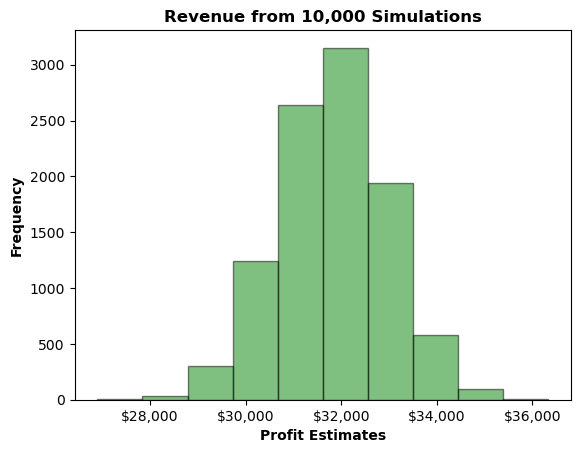

In [398]:
# 5. Plot a histogram of the 10,000 profit estimates.
tent_au, tent_nu, tent_rev = simulation(1000, 5000, 10000)

# Histogram check
fig, ax = plt.subplots()
ax.hist(tent_rev, alpha=0.5, edgecolor="black", color="green")
ax.set_title("Revenue from 10,000 Simulations", weight="bold")
ax.set_xlabel('Profit Estimates', weight="bold")
ax.set_ylabel('Frequency', weight="bold")
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.show()

In [399]:
# 6. Answer:
# What is the average simulated profit?
print(np.mean(tent_rev))

31825.60725953096


In [400]:
# What are the 5th and 95th percentiles of the simulated profit?
low, high = np.percentile(tent_rev, [2.5, 97.5])
print("5th and 95th Percentiles:", low, high)

5th and 95th Percentiles: 29560.998825876002 34043.7249288486


In [401]:
# Explain how we could use this information to guide future spending decisions.
# In the 5th percent worst case, how much money could they reasonably risk spending
# if they wanted to remain profitable for shareholders?
best = 292000 - low
worst = 292000 - high
print("Worst case:", worst, "\nBest case:", best)

Worst case: 257956.2750711514 
Best case: 262439.001174124
